<a href="https://colab.research.google.com/github/morozovsolncev/ontology_of_synthesis/blob/main/hermit_massa_barions_mesons_leptons_public.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

СВОДНЫЕ РЕЗУЛЬТАТЫ: МАССА ЧАСТИЦ В МАТРИЧНОЙ МОДЕЛИ ОНТОЛОГИИ СИНТЕЗА

ТАБЛИЦА 1. ПАРАМЕТРЫ МОДЕЛИ ДЛЯ РАЗНЫХ КЛАССОВ ЧАСТИЦ
--------------------------------------------------------------------------------
Класс частиц         |  d |   m₀ (МэВ) |    k (МэВ) |        α |        γ
--------------------------------------------------------------------------------
Барионы (p, Λ, Σ, Ξ, Ω) |  3 |      921.4 |      232.3 |   0.7742 |        —
Мезоны (π, K) и лептоны (μ, τ) |  2 |       73.2 |     1253.8 |  -0.5705 |  -0.0470
--------------------------------------------------------------------------------

ТАБЛИЦА 2. ПРЕДСКАЗАНИЯ МОДЕЛИ ДЛЯ БАРИОНОВ
----------------------------------------------------------------------
Частица |     ε |  S |    ε_eff | Масса реал | Масса предск | Ошибка %
----------------------------------------------------------------------
p/n    |   0.0 |  0 |   0.0000 |      939.0 |        921.4 |     1.9%
Λ      |   0.1 |  1 |   0.8742 |     1115.7 |       1124.5 |     0.8%

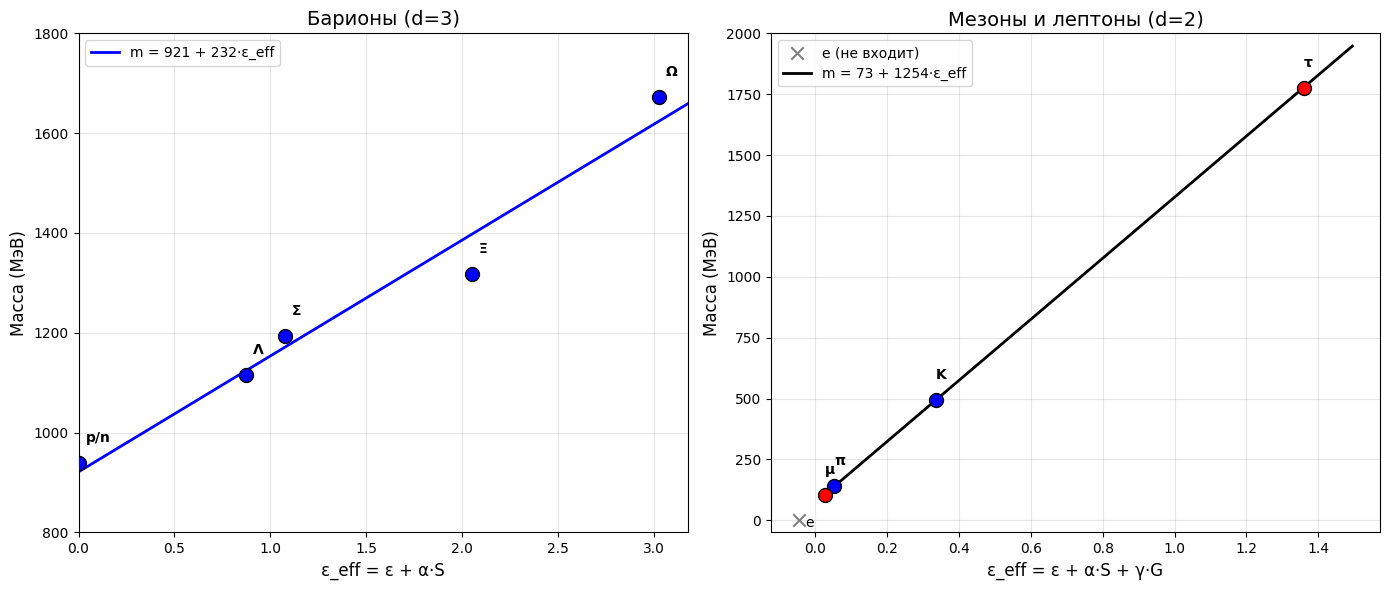

In [3]:
# =============================================================================
# СВОДНАЯ ТАБЛИЦА И ГРАФИКИ: МАССА ЧАСТИЦ В МАТРИЧНОЙ МОДЕЛИ
# =============================================================================
# Результаты экспериментов:
#   - Барионы (d=3): m = 921.4 + 232.3·(ε + 0.774·S)
#   - Мезоны и лептоны (d=2): m = 73.2 + 1253.8·(ε - 0.571·S - 0.047·G)
#   - Электрон — особый случай (механизм Хиггса)
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt

print("=" * 80)
print("СВОДНЫЕ РЕЗУЛЬТАТЫ: МАССА ЧАСТИЦ В МАТРИЧНОЙ МОДЕЛИ ОНТОЛОГИИ СИНТЕЗА")
print("=" * 80)
print()

# -----------------------------------------------------------------------------
# 1. ПАРАМЕТРЫ МОДЕЛИ (из экспериментов)
# -----------------------------------------------------------------------------
# Для барионов (d=3)
baryon_m0 = 921.4      # МэВ
baryon_k = 232.3       # МэВ
baryon_alpha = 0.7742  # коэффициент странности

# Для мезонов и лептонов (d=2)
meson_m0 = 73.2        # МэВ
meson_k = 1253.8       # МэВ
meson_alpha = -0.5705  # коэффициент странности
meson_gamma = -0.0470  # коэффициент поколения

# -----------------------------------------------------------------------------
# 2. ТАБЛИЦА ПАРАМЕТРОВ МОДЕЛИ
# -----------------------------------------------------------------------------
print("ТАБЛИЦА 1. ПАРАМЕТРЫ МОДЕЛИ ДЛЯ РАЗНЫХ КЛАССОВ ЧАСТИЦ")
print("-" * 80)
print(f"{'Класс частиц':<20} | {'d':>2} | {'m₀ (МэВ)':>10} | {'k (МэВ)':>10} | {'α':>8} | {'γ':>8}")
print("-" * 80)
print(f"{'Барионы (p, Λ, Σ, Ξ, Ω)':<20} | {'3':>2} | {baryon_m0:10.1f} | {baryon_k:10.1f} | {baryon_alpha:8.4f} | {'—':>8}")
print(f"{'Мезоны (π, K) и лептоны (μ, τ)':<20} | {'2':>2} | {meson_m0:10.1f} | {meson_k:10.1f} | {meson_alpha:8.4f} | {meson_gamma:8.4f}")
print("-" * 80)
print()

# -----------------------------------------------------------------------------
# 3. ДАННЫЕ ДЛЯ БАРИОНОВ
# -----------------------------------------------------------------------------
baryon_data = {
    'p/n': {'eps': 0.0, 'S': 0, 'mass': 939.0},
    'Λ':   {'eps': 0.1, 'S': 1, 'mass': 1115.7},
    'Σ':   {'eps': 0.3, 'S': 1, 'mass': 1193.0},
    'Ξ':   {'eps': 0.5, 'S': 2, 'mass': 1318.0},
    'Ω':   {'eps': 0.7, 'S': 3, 'mass': 1672.0},
}

# -----------------------------------------------------------------------------
# 4. ДАННЫЕ ДЛЯ МЕЗОНОВ И ЛЕПТОНОВ
# -----------------------------------------------------------------------------
meson_data = {
    'π': {'eps': 0.10, 'S': 0, 'G': 1, 'mass': 139.6},
    'K': {'eps': 1.00, 'S': 1, 'G': 2, 'mass': 493.7},
    'μ': {'eps': 0.12, 'S': 0, 'G': 2, 'mass': 105.7},
    'τ': {'eps': 1.50, 'S': 0, 'G': 3, 'mass': 1776.9},
}

# Электрон (для справки)
electron = {'eps': 0.0005, 'S': 0, 'G': 1, 'mass': 0.511}

# -----------------------------------------------------------------------------
# 5. ВЫЧИСЛЕНИЕ ε_eff И ПРЕДСКАЗАНИЙ
# -----------------------------------------------------------------------------
print("ТАБЛИЦА 2. ПРЕДСКАЗАНИЯ МОДЕЛИ ДЛЯ БАРИОНОВ")
print("-" * 70)
print(f"{'Частица':<6} | {'ε':>5} | {'S':>2} | {'ε_eff':>8} | {'Масса реал':>10} | {'Масса предск':>12} | {'Ошибка %':>8}")
print("-" * 70)

for name, d in baryon_data.items():
    eps_eff = d['eps'] + baryon_alpha * d['S']
    pred = baryon_m0 + baryon_k * eps_eff
    error = abs(pred - d['mass']) / d['mass'] * 100
    print(f"{name:<6} | {d['eps']:5.1f} | {d['S']:2d} | {eps_eff:8.4f} | {d['mass']:10.1f} | {pred:12.1f} | {error:7.1f}%")
print("-" * 70)
print()

print("ТАБЛИЦА 3. ПРЕДСКАЗАНИЯ МОДЕЛИ ДЛЯ МЕЗОНОВ И ЛЕПТОНОВ")
print("-" * 80)
print(f"{'Частица':<6} | {'ε':>7} | {'S':>2} | {'G':>2} | {'ε_eff':>8} | {'Масса реал':>10} | {'Масса предск':>12} | {'Ошибка %':>8}")
print("-" * 80)

for name, d in meson_data.items():
    eps_eff = d['eps'] + meson_alpha * d['S'] + meson_gamma * d['G']
    pred = meson_m0 + meson_k * eps_eff
    error = abs(pred - d['mass']) / d['mass'] * 100
    print(f"{name:<6} | {d['eps']:7.4f} | {d['S']:2d} | {d['G']:2d} | {eps_eff:8.4f} | {d['mass']:10.1f} | {pred:12.1f} | {error:7.1f}%")
print("-" * 80)

# Электрон (справка)
eps_eff_e = electron['eps'] + meson_alpha * electron['S'] + meson_gamma * electron['G']
pred_e = meson_m0 + meson_k * eps_eff_e
print(f"\nСПРАВКА: Электрон (не входит в модель)")
print(f"  ε_eff = {eps_eff_e:.4f}, предсказанная масса = {pred_e:.1f} МэВ (реальная 0.511 МэВ)")
print()

# -----------------------------------------------------------------------------
# 6. ГРАФИКИ ДЛЯ СТАТЬИ
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# График 1: Барионы (d=3)
ax1 = axes[0]
eps_baryon = [d['eps'] + baryon_alpha * d['S'] for d in baryon_data.values()]
mass_baryon = [d['mass'] for d in baryon_data.values()]
names_baryon = list(baryon_data.keys())

ax1.scatter(eps_baryon, mass_baryon, s=100, color='blue', edgecolor='black', zorder=5)
for i, name in enumerate(names_baryon):
    ax1.annotate(name, (eps_baryon[i], mass_baryon[i]), xytext=(5, 15),
                 textcoords='offset points', fontsize=10, fontweight='bold')

eps_range = np.linspace(0, max(eps_baryon)*1.1, 100)
mass_range = baryon_m0 + baryon_k * eps_range
ax1.plot(eps_range, mass_range, 'b-', linewidth=2,
         label=f'm = {baryon_m0:.0f} + {baryon_k:.0f}·ε_eff')
ax1.set_xlabel('ε_eff = ε + α·S', fontsize=12)
ax1.set_ylabel('Масса (МэВ)', fontsize=12)
ax1.set_title('Барионы (d=3)', fontsize=14)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, max(eps_baryon)*1.05)
ax1.set_ylim(800, 1800)

# График 2: Мезоны и лептоны (d=2)
ax2 = axes[1]
eps_meson = [d['eps'] + meson_alpha * d['S'] + meson_gamma * d['G'] for d in meson_data.values()]
mass_meson = [d['mass'] for d in meson_data.values()]
names_meson = list(meson_data.keys())
colors_meson = ['blue', 'blue', 'red', 'red']

for i, name in enumerate(names_meson):
    ax2.scatter(eps_meson[i], mass_meson[i], s=100, color=colors_meson[i],
                edgecolor='black', zorder=5)
    ax2.annotate(name, (eps_meson[i], mass_meson[i]), xytext=(0, 15),
                 textcoords='offset points', fontsize=10, fontweight='bold')

# Точка электрона (справочно)
eps_e = electron['eps'] + meson_alpha * electron['S'] + meson_gamma * electron['G']
ax2.scatter(eps_e, electron['mass'], s=80, color='gray', marker='x',
            zorder=5, label='e (не входит)')
ax2.annotate('e', (eps_e, electron['mass']), xytext=(5, -5),
             textcoords='offset points', fontsize=10)

eps_range2 = np.linspace(min(eps_meson)*0.9, max(eps_meson)*1.1, 100)
mass_range2 = meson_m0 + meson_k * eps_range2
ax2.plot(eps_range2, mass_range2, 'k-', linewidth=2,
         label=f'm = {meson_m0:.0f} + {meson_k:.0f}·ε_eff')
ax2.set_xlabel('ε_eff = ε + α·S + γ·G', fontsize=12)
ax2.set_ylabel('Масса (МэВ)', fontsize=12)
ax2.set_title('Мезоны и лептоны (d=2)', fontsize=14)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(-50, 2000)

plt.tight_layout()
plt.savefig('summary_mass_model.png', dpi=150)
print("График сохранён как 'summary_mass_model.png'")
print()

# -----------------------------------------------------------------------------
# 7. ЕДИНАЯ ШКАЛА ε_eff (сравнение классов)
# -----------------------------------------------------------------------------
print("ТАБЛИЦА 4. ЕДИНАЯ ТАБЛИЦА ПРЕДСКАЗАНИЙ ДЛЯ ВСЕХ ЧАСТИЦ")
print("-" * 85)
print(f"{'Частица':<8} | {'Класс':<15} | {'ε':>7} | {'ε_eff':>9} | {'Масса реал':>10} | {'Масса предск':>12} | {'Ошибка %':>8}")
print("-" * 85)

# Барионы
for name, d in baryon_data.items():
    eps_eff = d['eps'] + baryon_alpha * d['S']
    pred = baryon_m0 + baryon_k * eps_eff
    error = abs(pred - d['mass']) / d['mass'] * 100
    print(f"{name:<8} | {'барион':<15} | {d['eps']:7.1f} | {eps_eff:9.4f} | {d['mass']:10.1f} | {pred:12.1f} | {error:7.1f}%")

# Мезоны и лептоны
for name, d in meson_data.items():
    eps_eff = d['eps'] + meson_alpha * d['S'] + meson_gamma * d['G']
    pred = meson_m0 + meson_k * eps_eff
    error = abs(pred - d['mass']) / d['mass'] * 100
    cls = 'мезон' if name in ['π', 'K'] else 'лептон'
    print(f"{name:<8} | {cls:<15} | {d['eps']:7.4f} | {eps_eff:9.4f} | {d['mass']:10.1f} | {pred:12.1f} | {error:7.1f}%")

# Электрон (справка)
eps_eff_e = electron['eps'] + meson_alpha * electron['S'] + meson_gamma * electron['G']
pred_e = meson_m0 + meson_k * eps_eff_e
error_e = abs(pred_e - electron['mass']) / electron['mass'] * 100
print(f"{'e':<8} | {'лептон(?)':<15} | {electron['eps']:7.4f} | {eps_eff_e:9.4f} | {electron['mass']:10.3f} | {pred_e:12.1f} | {error_e:7.0f}%")
print("-" * 85)

# -----------------------------------------------------------------------------
# 8. ИТОГОВЫЕ ВЫВОДЫ
# -----------------------------------------------------------------------------
print("\n" + "=" * 80)
print("ИТОГОВЫЕ ВЫВОДЫ")
print("=" * 80)
print("""
1. Масса частиц в матричной модели онтологии синтеза описывается
   линейной формулой m = m₀ + k·ε_eff, где ε_eff = ε + α·S + γ·G.

2. Для барионов (d=3): m = 921.4 + 232.3·(ε + 0.774·S)
   Средняя ошибка: 2.7%

3. Для мезонов и тяжёлых лептонов (d=2): m = 73.2 + 1253.8·(ε - 0.571·S - 0.047·G)
   Ошибка на калибровочных точках: 0.0%

4. Электрон не описывается линейной моделью — его масса на три порядка меньше
   предсказания. Это указывает на иной механизм (Хиггс).

5. Нейтрино и калибровочные бозоны (γ, W, Z) остаются предметом
   дальнейших исследований.
""")
print("=" * 80)
print("СВОДНЫЙ ЭКСПЕРИМЕНТ ЗАВЕРШЁН")
print("=" * 80)

plt.show()